                 Coef.  Std.Err.         z         P>|z|    [0.025    0.975]
entrant_post -0.342631  0.049299 -6.950089  3.650565e-12 -0.439255 -0.246007
log_gdp_pc    0.170258  0.073233  2.324889  2.007788e-02  0.026724  0.313792
unemployment  0.017680  0.011417  1.548514  1.214987e-01 -0.004698  0.040058

R-squared: 0.67
Countries: 6 Years: 1991 - 2023
Observations: 196


/home/master/Documents/competitions/cirsDataSet/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 35, but rank is 5
  warnings.warn('covariance of constraints does not have full '


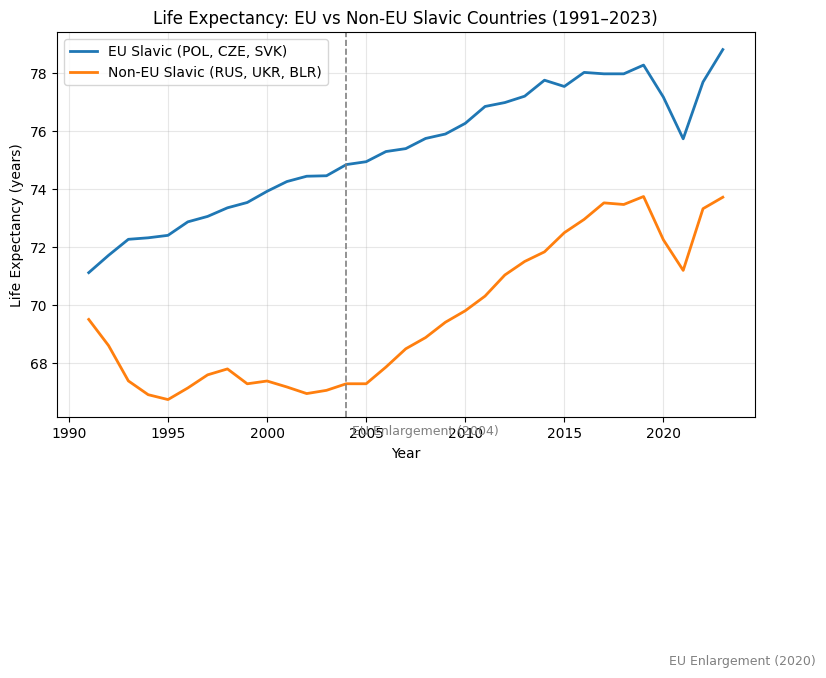

In [ ]:
# ===============================================================
# Q5: Did life-expectancy gains accelerate in EU entrants
#     (Poland, Czechia, Slovakia) vs. non-EU Slavic peers
#     (Russia, Ukraine, Belarus), controlling for GDP and unemployment?
# ===============================================================

import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

# ---------------------------------------------------------------
# 1. Load WDI data (make sure WDICSV.csv is in your working folder)
# ---------------------------------------------------------------
wdi = pd.read_csv("../data/raw/WDICSV.csv")

# Select indicators
codes = ["SP.DYN.LE00.IN", "NY.GDP.PCAP.KD", "SL.UEM.TOTL.ZS"]
df = wdi[wdi["Indicator Code"].isin(codes)].copy()

# Melt to long format
df_long = df.melt(
    id_vars=["Country Name", "Country Code", "Indicator Name", "Indicator Code"],
    var_name="year", value_name="value"
)
df_long["year"] = pd.to_numeric(df_long["year"], errors="coerce")
df_long = df_long.dropna(subset=["year", "value"])

# Pivot to wide (one row per country-year)
panel = df_long.pivot_table(
    index=["Country Name", "Country Code", "year"],
    columns="Indicator Code", values="value"
).reset_index()

panel = panel.rename(columns={
    "SP.DYN.LE00.IN": "life_expectancy",
    "NY.GDP.PCAP.KD": "gdp_pc",
    "SL.UEM.TOTL.ZS": "unemployment"
})

# ---------------------------------------------------------------
# 2. Define Slavic countries
# ---------------------------------------------------------------
slavic_eu = ["Poland", "Czechia", "Slovak Republic"]
slavic_noneu = ["Russian Federation", "Ukraine", "Belarus"]
panel = panel[panel["Country Name"].isin(slavic_eu + slavic_noneu)].copy()

# EU accession year mapping
entry_years = {"Poland": 2004, "Czechia": 2004, "Slovak Republic": 2004}
panel["entry_year"] = panel["Country Name"].map(entry_years)
panel["entrant"] = panel["entry_year"].notna().astype(int)
panel["post"] = ((panel["year"] >= panel["entry_year"]) & panel["entrant"].eq(1)).astype(int)
panel["entrant_post"] = panel["entrant"] * panel["post"]

# ---------------------------------------------------------------
# 3. Compute derived variables
# ---------------------------------------------------------------
panel = panel.sort_values(["Country Name", "year"])
panel["d_lifeexp"] = panel.groupby("Country Name")["life_expectancy"].diff()
panel["log_gdp_pc"] = np.log(panel["gdp_pc"])
panel = panel[panel["year"] >= 1990]
panel = panel.dropna(subset=["d_lifeexp", "log_gdp_pc", "unemployment", "entrant_post"])

# ---------------------------------------------------------------
# 4. Run regression with year fixed effects and clustered SEs
# ---------------------------------------------------------------
model = smf.ols("d_lifeexp ~ entrant_post + log_gdp_pc + unemployment + C(year)", data=panel)
res = model.fit(cov_type="cluster", cov_kwds={"groups": panel["Country Code"]})

print(res.summary2().tables[1].loc[["entrant_post", "log_gdp_pc", "unemployment"]])
print("\nR-squared:", round(res.rsquared, 3))
print("Countries:", panel['Country Code'].nunique(), "Years:", panel['year'].min(), "-", panel['year'].max())
print("Observations:", int(res.nobs))

# ---------------------------------------------------------------
# 5. Plot average life expectancy trends
# ---------------------------------------------------------------


# ---------------------------------------------------------------
# 6. Optional: Export modeling dataset
# ---------------------------------------------------------------
# panel.to_csv("q5_slavic_dataset.csv", index=False)


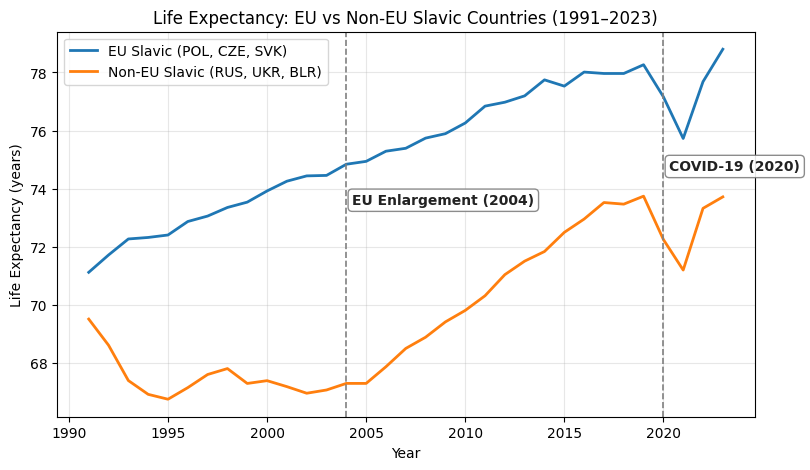

In [19]:
trend = (
    panel.dropna(subset=["life_expectancy"])
    .groupby(["year", "entrant"])["life_expectancy"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9,5))
for g, lab, col in [(1, "EU Slavic (POL, CZE, SVK)", "tab:blue"),
                    (0, "Non-EU Slavic (RUS, UKR, BLR)", "tab:orange")]:
    m = trend[trend["entrant"] == g]
    ax.plot(m["year"], m["life_expectancy"], label=lab, lw=2, color=col)

ax.axvline(2004, color="gray", linestyle="--", lw=1.2)
ax.text(
    2004.3,
    ax.get_ylim()[1] * 0.93,
    "EU Enlargement (2004)",
    color="#222222",
    fontsize=10,
    fontweight="bold",
    va="top",
    ha="left",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray", alpha=0.9),
)

ax.axvline(2020, color="gray", linestyle="--", lw=1.2)
ax.text(
    2020.3,
    ax.get_ylim()[0] + (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.65,
    "COVID-19 (2020)",
    color="#222222",
    fontsize=10,
    fontweight="bold",
    va="center",
    ha="left",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray", alpha=0.9),
)
ax.set_title("Life Expectancy: EU vs Non-EU Slavic Countries (1991–2023)")
ax.set_xlabel("Year")
ax.set_ylabel("Life Expectancy (years)")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

In [20]:
df

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
519,Africa Eastern and Southern,AFE,GDP per capita (constant 2015 US$),NY.GDP.PCAP.KD,1172.243576,1147.240329,1204.703044,1238.367092,1261.023946,1289.344084,...,1479.615260,1472.699230,1472.971152,1471.438317,1463.437891,1383.724119,1409.040699,1421.797169,1412.625384,1416.250369
749,Africa Eastern and Southern,AFE,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,44.169658,44.468838,44.877890,45.160583,45.535695,45.770723,...,61.713031,62.167981,62.591275,63.330691,63.857261,63.766484,62.979999,64.487020,65.146291,NaN
1468,Africa Eastern and Southern,AFE,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,7.036357,7.194666,7.346331,7.360513,7.584419,8.191395,8.577385,7.985202,7.806365,7.772654
2035,Africa Western and Central,AFW,GDP per capita (constant 2015 US$),NY.GDP.PCAP.KD,1122.268548,1119.450062,1136.671637,1190.566304,1227.326470,1249.709471,...,1860.727694,1815.168693,1808.716493,1814.688734,1829.070620,1768.313565,1796.602085,1824.953296,1841.758346,1873.200724
2265,Africa Western and Central,AFW,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,37.779636,38.058956,38.681792,38.936918,39.194580,39.479784,...,56.038336,56.392452,56.626439,57.036976,57.149847,57.364425,57.362572,57.987813,58.855722,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
400973,Zambia,ZMB,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,50.648000,51.041000,51.331000,51.605000,51.170000,52.079000,...,60.728000,61.129000,61.564000,62.138000,62.914000,63.361000,62.363000,65.279000,66.349000,NaN
401692,Zambia,ZMB,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,5.942000,5.239000,4.529000,5.033000,5.542000,6.033000,5.199000,5.995000,5.905000,5.961000
402259,Zimbabwe,ZWE,GDP per capita (constant 2015 US$),NY.GDP.PCAP.KD,1141.965643,1176.713594,1156.643827,1190.727981,1140.995313,1159.851504,...,1386.418559,1377.639277,1422.193460,1471.394890,1356.838211,1230.191557,1311.531000,1368.498418,1417.557759,1420.803172
402489,Zimbabwe,ZWE,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,53.492000,53.966000,54.453000,54.942000,55.431000,55.905000,...,58.989000,59.760000,60.263000,60.906000,61.060000,61.530000,60.135000,62.360000,62.775000,NaN


In [ ]:
# ===============================================================
# Plot life expectancy for each Slavic country (1991–2023)
# ===============================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Ensure only the six Slavic countries
slavic_countries = ["Poland", "Czechia", "Slovak Republic",
                    "Russian Federation", "Ukraine", "Belarus"]
df = panel_focus[panel_focus["Country Name"].isin(slavic_countries)].copy()

# Compute country-specific mean life expectancy per year
df_plot = df.dropna(subset=["life_expectancy"]).copy()

# --- Plot setup ---
plt.figure(figsize=(10,6))
sns.set_style("whitegrid")

palette = {
    "Poland": "royalblue",
    "Czechia": "cornflowerblue",
    "Slovak Republic": "deepskyblue",
    "Russian Federation": "darkorange",
    "Ukraine": "orangered",
    "Belarus": "gold"
}

for c in slavic_countries:
    subset = df_plot[df_plot["Country Name"] == c]
    plt.plot(subset["year"], subset["life_expectancy"],
             label=c, lw=2, color=palette[c])

# EU enlargement marker
plt.axvline(2004, color="gray", linestyle="--", lw=1.2)
plt.text(2004.3, plt.ylim()[1]*0.96, "EU Enlargement (2004)", color="gray", fontsize=9, va="top")

# COVID-period shading
plt.axvspan(2020, 2022.5, color="lightgray", alpha=0.4, label="COVID-19 period")

plt.title("Life Expectancy in Slavic EU vs Non-EU Countries (1991–2023)")
plt.xlabel("Year")
plt.ylabel("Life Expectancy (years)")
plt.legend(title="Country", loc="lower right", ncol=2)
plt.tight_layout()
plt.show()


NameError: name 'panel_focus' is not defined

In [28]:
df2 = pd.read_csv("../data/proceed/interest_rate.csv")

In [35]:
df2[df2["Indicator_Code"] == "SE.SEC.ENRR"]

,Country_Name,Country_Code,Indicator_Name,Indicator_Code,1960,1961,1962,1963,1964,1965,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
1301,Belarus,BLR,"School enrollment, secondary (% gross)",SE.SEC.ENRR,NaN,NaN,NaN,NaN,NaN,NaN,...,97.520332,97.048088,96.011772,95.499718,94.920532,95.007469,95.213387,94.535896,93.599510,NaN
2817,Czechia,CZE,"School enrollment, secondary (% gross)",SE.SEC.ENRR,NaN,NaN,NaN,NaN,NaN,NaN,...,104.810516,103.015083,102.204697,101.514893,100.215569,99.329262,102.089943,102.935562,NaN,NaN
4333,Poland,POL,"School enrollment, secondary (% gross)",SE.SEC.ENRR,NaN,NaN,NaN,NaN,NaN,NaN,...,109.414787,109.117249,109.459221,110.541939,109.753304,112.576263,110.529701,108.482170,NaN,NaN
5849,Russian Federation,RUS,"School enrollment, secondary (% gross)",SE.SEC.ENRR,NaN,NaN,NaN,NaN,NaN,NaN,...,96.329262,95.914268,97.520630,99.213501,100.471741,92.752251,93.341560,93.935387,92.484047,NaN
7365,Slovak Republic,SVK,"School enrollment, secondary (% gross)",SE.SEC.ENRR,NaN,NaN,NaN,NaN,NaN,NaN,...,91.895729,91.453438,91.253593,91.781540,91.324692,90.813347,91.089912,92.204308,NaN,NaN
8881,Ukraine,UKR,"School enrollment, secondary (% gross)",SE.SEC.ENRR,NaN,NaN,NaN,NaN,NaN,NaN,...,90.502899,88.545753,86.788696,85.833191,84.456833,84.428329,84.651627,NaN,NaN,NaN


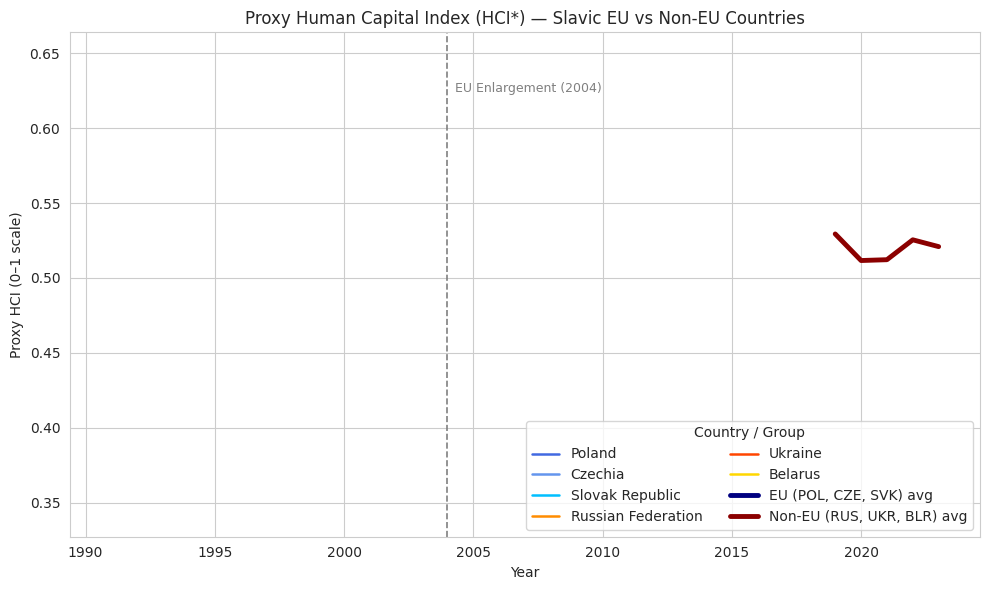

In [37]:
# ===============================================================
# Slavic EU vs Non-EU Proxy Human Capital Index (HCI*) with Stunting
# ===============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Load WDI file you uploaded ---
wdi = pd.read_csv("../data/raw/WDICSV.csv")

# --- Select indicators for survival, education, health ---
codes = {
    "SP.DYN.LE00.IN": "life_expectancy",   # Survival
    "SE.SEC.ENRR": "secondary_enroll",     # Education
    "SH.STA.STNT.ZS": "stunting"           # Early health / nutrition
}
df = wdi[wdi["Indicator Code"].isin(codes.keys())].copy()

# --- Reshape to panel format ---
df_long = df.melt(
    id_vars=["Country Name", "Country Code", "Indicator Code"],
    var_name="year", value_name="value"
)
df_long["year"] = pd.to_numeric(df_long["year"], errors="coerce")
df_long = df_long.dropna(subset=["year", "value"])

panel = df_long.pivot_table(
    index=["Country Name", "Country Code", "year"],
    columns="Indicator Code",
    values="value"
).reset_index().rename(columns=codes)

# --- Normalize pillars to [0,1] ---
for col in ["life_expectancy", "secondary_enroll"]:
    panel[col + "_norm"] = (panel[col] - panel[col].min()) / (panel[col].max() - panel[col].min())

# Invert stunting so higher = healthier
panel["stunting_norm"] = 1 - (panel["stunting"] - panel["stunting"].min()) / (panel["stunting"].max() - panel["stunting"].min())

# --- Multiplicative proxy ---
panel["hci_proxy"] = (
    panel["life_expectancy_norm"] *
    panel["secondary_enroll_norm"] *
    panel["stunting_norm"]
)
panel["hci_proxy"] = panel["hci_proxy"] / panel["hci_proxy"].max()

# --- Filter Slavic countries ---
slavic_eu = ["Poland", "Czechia", "Slovak Republic"]
slavic_noneu = ["Russian Federation", "Ukraine", "Belarus"]
panel_s = panel[panel["Country Name"].isin(slavic_eu + slavic_noneu)].copy()

# --- Label groups ---
panel_s["Group"] = panel_s["Country Name"].apply(
    lambda x: "EU (POL, CZE, SVK)" if x in slavic_eu else "Non-EU (RUS, UKR, BLR)"
)

# --- Compute yearly group means ---
trend = panel_s.groupby(["year", "Group"])["hci_proxy"].mean().reset_index()

# --- Plot ---
plt.figure(figsize=(10,6))
sns.set_style("whitegrid")

palette = {
    "Poland": "royalblue",
    "Czechia": "cornflowerblue",
    "Slovak Republic": "deepskyblue",
    "Russian Federation": "darkorange",
    "Ukraine": "orangered",
    "Belarus": "gold"
}

# Country lines
for c in slavic_eu + slavic_noneu:
    sub = panel_s[panel_s["Country Name"] == c]
    plt.plot(sub["year"], sub["hci_proxy"], lw=1.8, color=palette[c], label=c)

# Group averages
for g, col in [("EU (POL, CZE, SVK)", "navy"), ("Non-EU (RUS, UKR, BLR)", "darkred")]:
    gdata = trend[trend["Group"] == g]
    plt.plot(gdata["year"], gdata["hci_proxy"], lw=3.5, color=col, label=f"{g} avg")

plt.axvline(2004, color="gray", linestyle="--", lw=1.2)
plt.text(2004.3, plt.ylim()[1]*0.95, "EU Enlargement (2004)", color="gray", fontsize=9, va="top")

plt.title("Proxy Human Capital Index (HCI*) — Slavic EU vs Non-EU Countries")
plt.xlabel("Year")
plt.ylabel("Proxy HCI (0–1 scale)")
plt.legend(title="Country / Group", loc="lower right", ncol=2)
plt.tight_layout()
plt.show()


✅ Indicators present in dataset: {'SH.STA.STNT.ZS', 'SP.DYN.LE00.IN', 'SE.SEC.ENRR'}


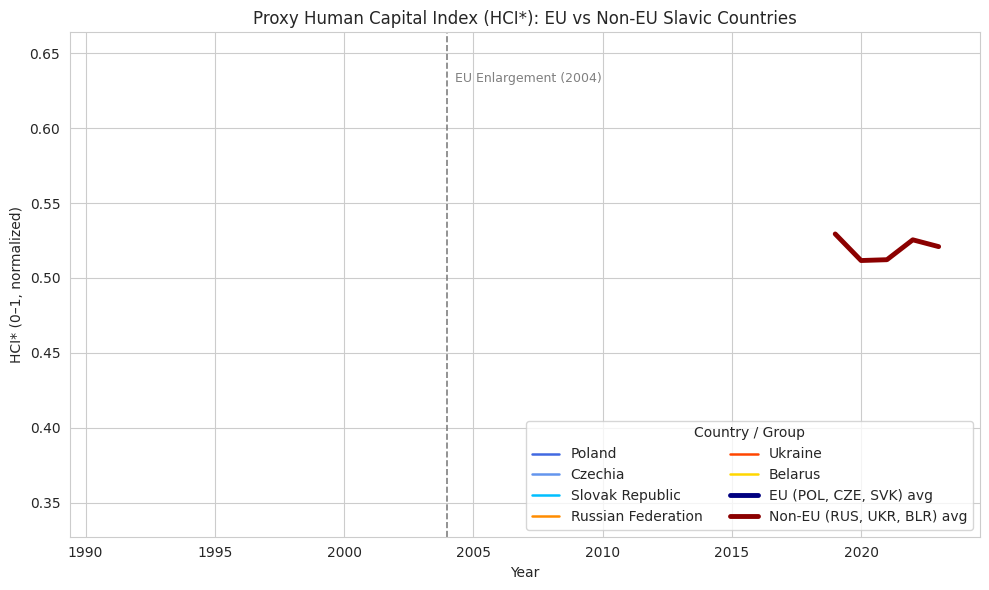

In [39]:
# ===============================================================
# Proxy Human Capital Index (HCI*) = Survival × Education × Health (Stunting)
# Slavic EU vs Non-EU Countries
# ===============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------------
# 1. Load and verify indicators
# ---------------------------------------------------------------
wdi = pd.read_csv("../data/raw/WDICSV.csv")

codes = {
    "SP.DYN.LE00.IN": "life_expectancy",   # Survival
    "SE.SEC.ENRR": "secondary_enroll",     # Education
    "SH.STA.STNT.ZS": "stunting"           # Early health (inverse)
}

present = set(wdi["Indicator Code"]).intersection(codes.keys())
print("✅ Indicators present in dataset:", present)
missing = set(codes.keys()) - present
if missing:
    print("⚠️ Missing indicators:", missing)

# ---------------------------------------------------------------
# 2. Prepare panel data
# ---------------------------------------------------------------
df = wdi[wdi["Indicator Code"].isin(present)].copy()

df_long = df.melt(
    id_vars=["Country Name", "Country Code", "Indicator Code"],
    var_name="year", value_name="value"
)
df_long["year"] = pd.to_numeric(df_long["year"], errors="coerce")
df_long = df_long.dropna(subset=["year", "value"])

panel = df_long.pivot_table(
    index=["Country Name", "Country Code", "year"],
    columns="Indicator Code",
    values="value"
).reset_index().rename(columns=codes)

# ---------------------------------------------------------------
# 3. Normalize indicators to [0,1]
# ---------------------------------------------------------------
for col in ["life_expectancy", "secondary_enroll"]:
    if col in panel:
        panel[col + "_norm"] = (panel[col] - panel[col].min()) / (panel[col].max() - panel[col].min())

if "stunting" in panel:
    # invert so higher = healthier
    panel["stunting_norm"] = 1 - (panel["stunting"] - panel["stunting"].min()) / (panel["stunting"].max() - panel["stunting"].min())

# ---------------------------------------------------------------
# 4. Compute multiplicative proxy HCI*
# ---------------------------------------------------------------
panel["hci_proxy"] = (
    panel.get("life_expectancy_norm", 1)
    * panel.get("secondary_enroll_norm", 1)
    * panel.get("stunting_norm", 1)
)
panel["hci_proxy"] = panel["hci_proxy"] / panel["hci_proxy"].max()

# ---------------------------------------------------------------
# 5. Filter to Slavic EU vs Non-EU countries
# ---------------------------------------------------------------
slavic_eu = ["Poland", "Czechia", "Slovak Republic"]
slavic_noneu = ["Russian Federation", "Ukraine", "Belarus"]
panel_s = panel[panel["Country Name"].isin(slavic_eu + slavic_noneu)].copy()
panel_s["Group"] = panel_s["Country Name"].apply(
    lambda x: "EU (POL, CZE, SVK)" if x in slavic_eu else "Non-EU (RUS, UKR, BLR)"
)

# ---------------------------------------------------------------
# 6. Compute group averages and plot
# ---------------------------------------------------------------
group_trend = panel_s.groupby(["year", "Group"])["hci_proxy"].mean().reset_index()

plt.figure(figsize=(10,6))
sns.set_style("whitegrid")

palette = {
    "Poland": "royalblue",
    "Czechia": "cornflowerblue",
    "Slovak Republic": "deepskyblue",
    "Russian Federation": "darkorange",
    "Ukraine": "orangered",
    "Belarus": "gold"
}

# Individual countries
for c in slavic_eu + slavic_noneu:
    subset = panel_s[panel_s["Country Name"] == c]
    plt.plot(subset["year"], subset["hci_proxy"], lw=1.8, color=palette.get(c,"gray"), label=c)

# Group averages
for g, col in [("EU (POL, CZE, SVK)", "navy"), ("Non-EU (RUS, UKR, BLR)", "darkred")]:
    gdata = group_trend[group_trend["Group"] == g]
    plt.plot(gdata["year"], gdata["hci_proxy"], lw=3.5, color=col, label=f"{g} avg")

plt.axvline(2004, color="gray", linestyle="--", lw=1.2)
plt.text(2004.3, plt.ylim()[1]*0.96, "EU Enlargement (2004)", color="gray", fontsize=9, va="top")

plt.title("Proxy Human Capital Index (HCI*): EU vs Non-EU Slavic Countries")
plt.xlabel("Year")
plt.ylabel("HCI* (0–1, normalized)")
plt.legend(title="Country / Group", loc="lower right", ncol=2)
plt.tight_layout()
plt.show()


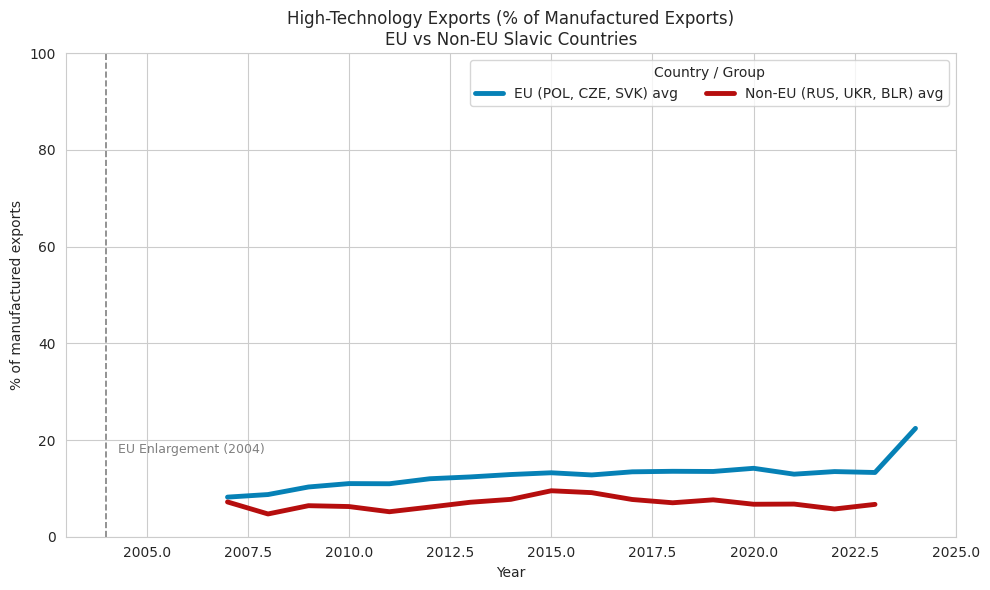

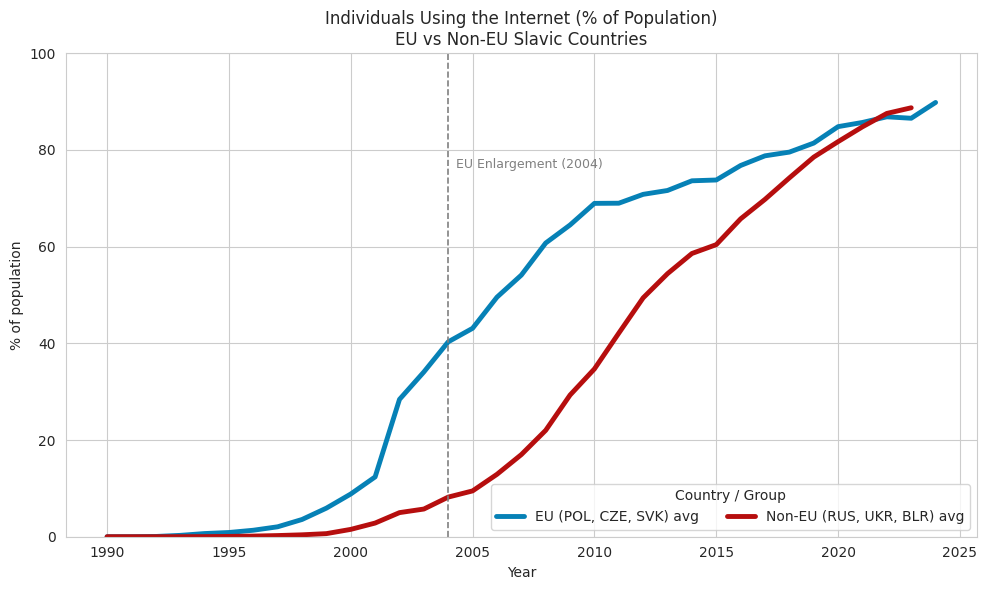

In [49]:
# ===============================================================
# Modern Technology Indicators: EU vs Non-EU Slavic Countries
# ===============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Load dataset ---
wdi = pd.read_csv("../data/raw/WDICSV.csv")

# --- Choose indicators ---
indicators = {
    "TX.VAL.TECH.MF.ZS": "High-tech exports (% of manufactured exports)",
    "IT.NET.USER.ZS": "Individuals using the Internet (% of population)"
}

df = wdi[wdi["Indicator Code"].isin(indicators.keys())].copy()

# --- Long format ---
df_long = df.melt(
    id_vars=["Country Name", "Country Code", "Indicator Code"],
    var_name="year", value_name="value"
)
df_long["year"] = pd.to_numeric(df_long["year"], errors="coerce")
df_long = df_long.dropna(subset=["year", "value"])

group_colors = {
        "EU (POL, CZE, SVK)": "#0681B6",
        "Non-EU (RUS, UKR, BLR)": "#b60e0e",
    }


# --- Country groups ---
slavic_eu = ["Poland", "Czechia", "Slovak Republic"]
slavic_noneu = ["Russian Federation", "Ukraine", "Belarus"]
df_long = df_long[df_long["Country Name"].isin(slavic_eu + slavic_noneu)].copy()
df_long["Group"] = df_long["Country Name"].apply(
    lambda x: "EU (POL, CZE, SVK)" if x in slavic_eu else "Non-EU (RUS, UKR, BLR)"
)

# --- Function for plotting each indicator ---
def plot_indicator(code, title, ylabel, filename):
    data = df_long[df_long["Indicator Code"] == code]
    group_trend = data.groupby(["year", "Group"])["value"].mean().reset_index()

    plt.figure(figsize=(10,6))
    sns.set_style("whitegrid")

    # Individual countries
    palette = {
        "Poland": "royalblue",
        "Czechia": "cornflowerblue",
        "Slovak Republic": "deepskyblue",
        "Russian Federation": "darkorange",
        "Ukraine": "orangered",
        "Belarus": "gold"
    }

    # for c in slavic_eu + slavic_noneu:
    #     subset = data[data["Country Name"] == c]
    #     plt.plot(subset["year"], subset["value"], lw=1.8,
    #              color=palette.get(c, "gray"), label=c)

    # Group averages
    for g, col in group_colors.items():
        gdata = group_trend[group_trend["Group"] == g]
        plt.plot(gdata["year"], gdata["value"], lw=3.5, color=col, label=f"{g} avg")

    plt.axvline(2004, color="gray", linestyle="--", lw=1.2)
    plt.text(2004.3, plt.ylim()[1]*0.83, "EU Enlargement (2004)", color="gray", fontsize=9, va="top")

    plt.title(title)
    plt.xlabel("Year")
    plt.ylabel(ylabel)
    plt.ylim(0, 100)  # show full 0–100% scale
    plt.legend(title="Country / Group", loc="best", ncol=2)
    plt.tight_layout()
    plt.show()

# --- Plot 1: High-tech exports ---
plot_indicator("TX.VAL.TECH.MF.ZS",
               "High-Technology Exports (% of Manufactured Exports)\nEU vs Non-EU Slavic Countries",
               "% of manufactured exports",
               "hightech_slavic.png")

# --- Plot 2: Internet users ---
plot_indicator("IT.NET.USER.ZS",
               "Individuals Using the Internet (% of Population)\nEU vs Non-EU Slavic Countries",
               "% of population",
               "internet_slavic.png")


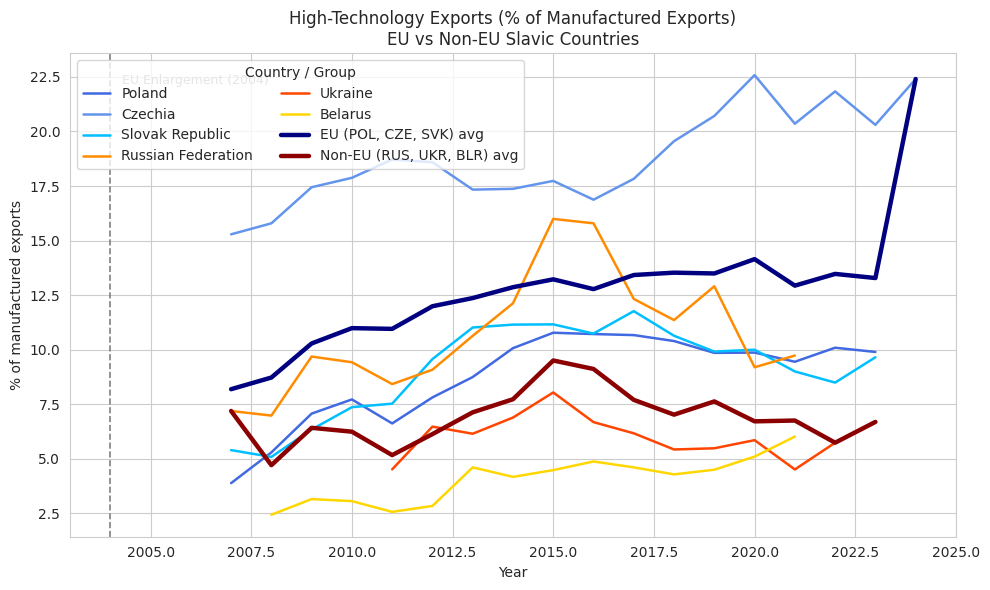

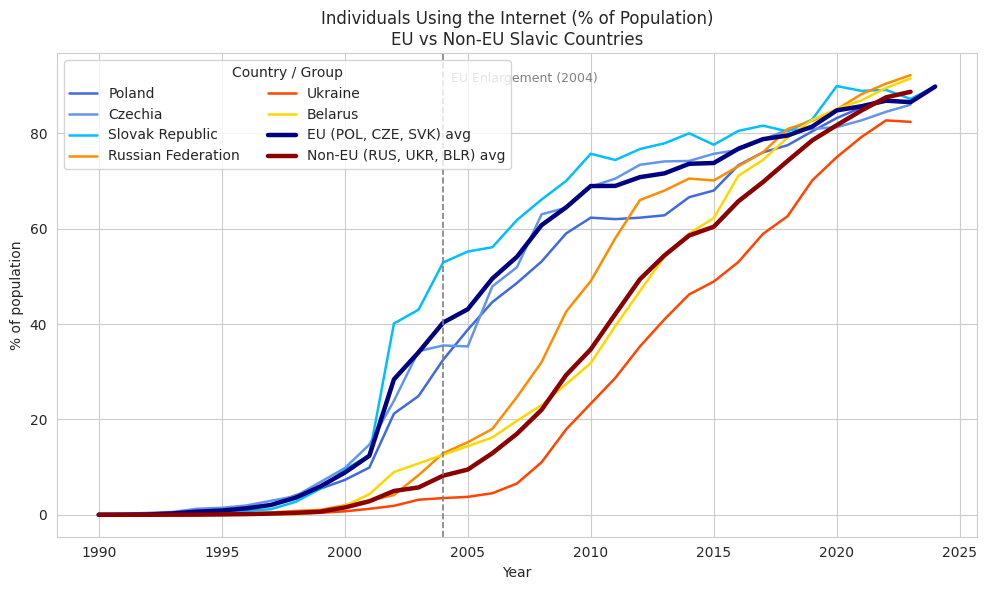

In [42]:
# ===============================================================
# Modern-Technology Trends in EU vs Non-EU Slavic Countries
# ===============================================================

import pandas as pd, matplotlib.pyplot as plt, seaborn as sns

wdi = pd.read_csv("../data/raw/WDICSV.csv")

indicators = {
    "TX.VAL.TECH.MF.ZS": "High-tech exports (% of manufactured exports)",
    "IT.NET.USER.ZS": "Individuals using the Internet (% of population)"
}
df = wdi[wdi["Indicator Code"].isin(indicators)].copy()

df_long = df.melt(
    id_vars=["Country Name","Country Code","Indicator Code"],
    var_name="year", value_name="value"
)
df_long["year"] = pd.to_numeric(df_long["year"], errors="coerce")
df_long = df_long.dropna(subset=["year","value"])

eu  = ["Poland","Czechia","Slovak Republic"]
non = ["Russian Federation","Ukraine","Belarus"]
df_long = df_long[df_long["Country Name"].isin(eu+non)]
df_long["Group"] = df_long["Country Name"].apply(
    lambda c: "EU (POL, CZE, SVK)" if c in eu else "Non-EU (RUS, UKR, BLR)"
)

def plot(code, title, ylabel):
    d = df_long[df_long["Indicator Code"]==code]
    g = d.groupby(["year","Group"])["value"].mean().reset_index()
    plt.figure(figsize=(10,6)); sns.set_style("whitegrid")

    colors = {
        "Poland":"royalblue","Czechia":"cornflowerblue","Slovak Republic":"deepskyblue",
        "Russian Federation":"darkorange","Ukraine":"orangered","Belarus":"gold"
    }
    for c in eu+non:
        plt.plot(d.loc[d["Country Name"]==c,"year"],
                 d.loc[d["Country Name"]==c,"value"],
                 lw=1.8, color=colors[c], label=c)

    for grp,col in [("EU (POL, CZE, SVK)","navy"),("Non-EU (RUS, UKR, BLR)","darkred")]:
        sub=g[g["Group"]==grp]
        plt.plot(sub["year"], sub["value"], lw=3.2, color=col, label=f"{grp} avg")

    plt.axvline(2004,color="gray",ls="--",lw=1.2)
    plt.text(2004.3, plt.ylim()[1]*0.96,"EU Enlargement (2004)",color="gray",fontsize=9,va="top")
    plt.title(title); plt.xlabel("Year"); plt.ylabel(ylabel)
    plt.legend(title="Country / Group",loc="best",ncol=2); plt.tight_layout(); plt.show()

plot("TX.VAL.TECH.MF.ZS",
     "High-Technology Exports (% of Manufactured Exports)\nEU vs Non-EU Slavic Countries",
     "% of manufactured exports")

plot("IT.NET.USER.ZS",
     "Individuals Using the Internet (% of Population)\nEU vs Non-EU Slavic Countries",
     "% of population")
